# Model Comparison :)

### Models used for comparison
- Linear Regression (baseline)
- Extra Trees

### Evaluation metrics
- RMSE
- R²

## import + load dataset

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import ExtraTreesRegressor

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [3]:
# load new dataset
df = pd.read_csv("../data/cleaned-engineered.csv")

print(df.shape)
print(df.columns.tolist())
df.head()

(614534, 26)
['List Year', 'Date Recorded', 'Town', 'Assessed Value', 'Sale Amount', 'Property Type', 'Residential Type', 'Location', 'Sale Year', 'Sale Month', 'Sale Quarter', 'Sale Day Of Year', 'Assessment Ratio', 'Assessment Gap', 'Log Assessed Value', 'Latitude', 'Longitude', 'Dist To NYC', 'Dist To Hartford', 'Dist To Boston', 'Approx Dist To Coast', 'Town Median Sale Amount', 'Town Avg Assessment Ratio', 'Town Avg Sale Amount', 'Town Market Strength', 'Luxury Home']


,List Year,Date Recorded,Town,Assessed Value,Sale Amount,Property Type,Residential Type,Location,Sale Year,Sale Month,...,Longitude,Dist To NYC,Dist To Hartford,Dist To Boston,Approx Dist To Coast,Town Median Sale Amount,Town Avg Assessment Ratio,Town Avg Sale Amount,Town Market Strength,Luxury Home
0,2010,2010-10-02,Norwalk,339640.0,265000.0,Residential,Single Family,POINT (-73.408 41.118),2010,10,...,-73.408,41.936910,58.745280,148.427562,8.142,420000.0,1.876569,617242.675586,1.650295,0
1,2010,2010-10-03,Milford,674350.0,788000.0,Residential,Single Family,POINT (-73.057 41.222),2010,10,...,-73.057,60.737843,42.495549,129.526272,15.318,287000.0,1.496553,344579.129171,1.127701,0
2,2010,2010-10-04,Bridgeport,132250.0,148000.0,Residential,Single Family,POINT (-73.195 41.186),2010,10,...,-73.195,53.480470,48.310972,136.729259,12.834,160000.0,1.492121,212777.367623,0.628684,0
3,2010,2010-10-04,Bristol,99610.0,32000.0,Residential,Single Family,POINT (-72.94 41.671),2010,10,...,-72.940,86.341970,15.229990,107.661631,46.299,185000.0,1.731108,211111.211163,0.726916,0
4,2010,2010-10-04,Bridgeport,132260.0,110000.0,Residential,Single Family,POINT (-73.195 41.186),2010,10,...,-73.195,53.480470,48.310972,136.729259,12.834,160000.0,1.492121,212777.367623,0.628684,0


## decide preprocessing

In [4]:
# outlier trimming used in tree notebook
df = df[(df["Sale Amount"] >= 10000) & (df["Sale Amount"] <= 5000000)].copy()

print("rows after outlier trimming:", df.shape[0])

rows after outlier trimming: 609490


In [5]:
leakage_cols = [
    "Assessment Ratio",
    "Assessment Gap",
    "Town Avg Sale Amount",
    "Town Median Sale Amount",
    "Luxury Home",
    "Town Avg Assessment Ratio",
    "Town Market Strength"
]

existing_leakage_cols = [col for col in leakage_cols if col in df.columns]
df = df.drop(columns=existing_leakage_cols)

print("dropped leakage columns:", existing_leakage_cols)

dropped leakage columns: ['Assessment Ratio', 'Assessment Gap', 'Town Avg Sale Amount', 'Town Median Sale Amount', 'Luxury Home', 'Town Avg Assessment Ratio', 'Town Market Strength']


## define target + feature cols

In [6]:
# exclude target and other non-feature columns
drop_cols = ["Sale Amount", "Date Recorded", "Address", "Location"]

drop_cols = [col for col in drop_cols if col in df.columns]
X = df.drop(columns=drop_cols)
y = df["Sale Amount"]

print("feature count:", X.shape[1])
print(X.columns.tolist())

feature count: 16
['List Year', 'Town', 'Assessed Value', 'Property Type', 'Residential Type', 'Sale Year', 'Sale Month', 'Sale Quarter', 'Sale Day Of Year', 'Log Assessed Value', 'Latitude', 'Longitude', 'Dist To NYC', 'Dist To Hartford', 'Dist To Boston', 'Approx Dist To Coast']


In [7]:
# categorical vs numeric cols
categorical_cols = [col for col in ["Town", "Property Type", "Residential Type"] if col in X.columns]
numeric_cols = [col for col in X.columns if col not in categorical_cols]

print("categorical columns:", categorical_cols)
print("numeric columns:", numeric_cols)

bad_numeric = X[numeric_cols].select_dtypes(include=["object"]).columns.tolist()
print("object columns accidentally in numeric_cols:", bad_numeric)


categorical columns: ['Town', 'Property Type', 'Residential Type']
numeric columns: ['List Year', 'Assessed Value', 'Sale Year', 'Sale Month', 'Sale Quarter', 'Sale Day Of Year', 'Log Assessed Value', 'Latitude', 'Longitude', 'Dist To NYC', 'Dist To Hartford', 'Dist To Boston', 'Approx Dist To Coast']
object columns accidentally in numeric_cols: []


## train test split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print("training rows:", X_train.shape[0])
print("testing rows:", X_test.shape[0])

training rows: 426643
testing rows: 182847


In [9]:
y_train_log = np.log1p(y_train)

## preprocessing pipeline

In [10]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median"))
        ]), numeric_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_cols)
    ]
)

In [12]:
keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

# separate copies for the neural network path
X_train_nn = X_train.copy()
X_test_nn = X_test.copy()

# use embeddings only for these categorical columns
nn_categorical_cols = [col for col in ["Property Type", "Residential Type"] if col in X_train_nn.columns]

# ignore Town for the NN, and use all remaining columns as numeric
nn_numeric_cols = [col for col in X_train_nn.columns if col not in nn_categorical_cols + ["Town"]]

print("NN categorical columns:", nn_categorical_cols)
print("NN numeric columns:", nn_numeric_cols)

NN categorical columns: ['Property Type', 'Residential Type']
NN numeric columns: ['List Year', 'Assessed Value', 'Sale Year', 'Sale Month', 'Sale Quarter', 'Sale Day Of Year', 'Log Assessed Value', 'Latitude', 'Longitude', 'Dist To NYC', 'Dist To Hartford', 'Dist To Boston', 'Approx Dist To Coast']


In [15]:
# fill numeric missing values
X_train_nn[nn_numeric_cols] = X_train_nn[nn_numeric_cols].fillna(0)
X_test_nn[nn_numeric_cols] = X_test_nn[nn_numeric_cols].fillna(0)

# fill categorical missing values
for col in nn_categorical_cols:
    X_train_nn[col] = X_train_nn[col].fillna("Missing").astype(str)
    X_test_nn[col] = X_test_nn[col].fillna("Missing").astype(str)

# create safe integer mappings from training data only
nn_category_maps = {}

for col in nn_categorical_cols:
    train_values = sorted(X_train_nn[col].unique())
    mapping = {val: i + 1 for i, val in enumerate(train_values)}  # reserve 0 for unknown
    nn_category_maps[col] = mapping

    X_train_nn[col] = X_train_nn[col].map(mapping).fillna(0).astype("int32")
    X_test_nn[col] = X_test_nn[col].map(mapping).fillna(0).astype("int32")

# scale numeric features
nn_scaler_X = StandardScaler()
X_train_nn[nn_numeric_cols] = nn_scaler_X.fit_transform(X_train_nn[nn_numeric_cols])
X_test_nn[nn_numeric_cols] = nn_scaler_X.transform(X_test_nn[nn_numeric_cols])

# scale target values
nn_scaler_y = StandardScaler()
y_train_nn_scaled = nn_scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_test_nn_scaled = nn_scaler_y.transform(y_test.values.reshape(-1, 1))

print("NN preprocessing complete.")
print("X_train_nn shape:", X_train_nn.shape)
print("X_test_nn shape:", X_test_nn.shape)

NN preprocessing complete.
X_train_nn shape: (426643, 16)
X_test_nn shape: (182847, 16)


In [16]:
def prepare_nn_inputs(X_df, nn_numeric_cols):
    inputs = {
        "numeric": X_df[nn_numeric_cols].values.astype("float32")
    }

    for col in nn_categorical_cols:
        inputs[col] = X_df[col].values.astype("int32")

    return inputs

X_train_nn_dict = prepare_nn_inputs(X_train_nn, nn_numeric_cols)
X_test_nn_dict = prepare_nn_inputs(X_test_nn, nn_numeric_cols)

print("NN input keys:", X_train_nn_dict.keys())
for key, value in X_train_nn_dict.items():
    print(key, value.shape)

NN input keys: dict_keys(['numeric', 'Property Type', 'Residential Type'])
numeric (426643, 13)
Property Type (426643,)
Residential Type (426643,)


## define model

In [24]:
# linear regression (baseline) and extra trees (best model from tree notebook)
models = {
    "LinearRegression": LinearRegression(),
    "ExtraTrees": ExtraTreesRegressor(
        n_estimators=50,
        max_depth=None,
        n_jobs=-1,
        random_state=42
    )
}

In [20]:
nn_inputs = []

# numeric input
numeric_input = keras.Input(shape=(len(nn_numeric_cols),), name="numeric")
nn_inputs.append(numeric_input)

embedded_features = []

# Property Type embedding
if "Property Type" in nn_categorical_cols:
    ptype_input = keras.Input(shape=(1,), name="Property Type")
    nn_inputs.append(ptype_input)

    ptype_vocab_size = int(max(X_train_nn["Property Type"].max(), X_test_nn["Property Type"].max())) + 1
    ptype_embed = layers.Embedding(input_dim=ptype_vocab_size, output_dim=4)(ptype_input)
    ptype_embed = layers.Flatten()(ptype_embed)
    embedded_features.append(ptype_embed)

# Residential Type embedding
if "Residential Type" in nn_categorical_cols:
    rtype_input = keras.Input(shape=(1,), name="Residential Type")
    nn_inputs.append(rtype_input)

    rtype_vocab_size = int(max(X_train_nn["Residential Type"].max(), X_test_nn["Residential Type"].max())) + 1
    rtype_embed = layers.Embedding(input_dim=rtype_vocab_size, output_dim=4)(rtype_input)
    rtype_embed = layers.Flatten()(rtype_embed)
    embedded_features.append(rtype_embed)

# combine embedded categorical features with numeric input
if embedded_features:
    x = layers.Concatenate()(embedded_features + [numeric_input])
else:
    x = numeric_input

x = layers.Dense(128, activation="relu")(x)
x = layers.Dense(64, activation="relu")(x)
output = layers.Dense(1)(x)

nn_model = keras.Model(inputs=nn_inputs, outputs=output)
nn_model.compile(optimizer="adam", loss="mse", metrics=["mae"])

## train + evaluate models

In [26]:
print("fitting preprocessor...")

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

print("transformed training shape:", X_train_proc.shape)
print("transformed testing shape:", X_test_proc.shape)

fitting preprocessor...
transformed training shape: (426643, 193)
transformed testing shape: (182847, 193)


In [19]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = nn_model.fit(
    X_train_nn_dict,
    y_train_nn_scaled,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

y_pred_nn_scaled = nn_model.predict(X_test_nn_dict)
y_pred_nn = nn_scaler_y.inverse_transform(y_pred_nn_scaled).flatten()

nn_rmse = np.sqrt(mean_squared_error(y_test, y_pred_nn))
nn_r2 = r2_score(y_test, y_pred_nn)

print("NeuralNetwork RMSE:", nn_rmse)
print("NeuralNetwork R2:", nn_r2)

Epoch 1/10
10667/10667 ━━━━━━━━━━━━━━━━━━━━ 10s 931us/step - loss: 0.1978 - mae: 0.1940 - val_loss: 0.1934 - val_mae: 0.1969
Epoch 2/10
10667/10667 ━━━━━━━━━━━━━━━━━━━━ 10s 934us/step - loss: 0.1955 - mae: 0.1928 - val_loss: 0.1932 - val_mae: 0.1980
Epoch 3/10
10667/10667 ━━━━━━━━━━━━━━━━━━━━ 10s 919us/step - loss: 0.1942 - mae: 0.1917 - val_loss: 0.1929 - val_mae: 0.1962
Epoch 4/10
10667/10667 ━━━━━━━━━━━━━━━━━━━━ 10s 923us/step - loss: 0.1934 - mae: 0.1909 - val_loss: 0.1905 - val_mae: 0.1937
Epoch 5/10
10667/10667 ━━━━━━━━━━━━━━━━━━━━ 10s 935us/step - loss: 0.1905 - mae: 0.1908 - val_loss: 0.1883 - val_mae: 0.1943
Epoch 6/10
10667/10667 ━━━━━━━━━━━━━━━━━━━━ 10s 943us/step - loss: 0.1875 - mae: 0.1903 - val_loss: 0.1877 - val_mae: 0.1926
Epoch 7/10
10667/10667 ━━━━━━━━━━━━━━━━━━━━ 10s 960us/step - loss: 0.1904 - mae: 0.1904 - val_loss: 0.1887 - val_mae: 0.1922
Epoch 8/10
10667/10667 ━━━━━━━━━━━━━━━━━━━━ 10s 938us/step - loss: 0.1873 - mae: 0.1899 - val_loss: 0.1880 - val_mae: 0.1913


### cell below takes a hot min to run so beware (like 30 mins)

In [27]:
results = {}
fitted_models = {}

for name, regressor in models.items():
    print(f"training {name}...")

    regressor.fit(X_train_proc, y_train_log)

    y_pred_log = regressor.predict(X_test_proc)
    y_pred = np.expm1(y_pred_log)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results[name] = {
        "RMSE": rmse,
        "R2": r2
    }

    fitted_models[name] = regressor

results["NeuralNetwork"] = {
    "RMSE": nn_rmse,
    "R2": nn_r2
}

results_df = (
    pd.DataFrame(results)
    .T
    .reset_index()
    .rename(columns={"index": "Model"})
    .sort_values(by="R2", ascending=False)
)

results_df

training LinearRegression...
training ExtraTrees...


,Model,RMSE,R2
1,ExtraTrees,186315.329093,0.823701
2,NeuralNetwork,191844.418473,0.813082
0,LinearRegression,434144.440366,0.042758


## model comparison

In [28]:
# table
results_df = results_df.sort_values(by="R2", ascending=False)
results_df

,Model,RMSE,R2
1,ExtraTrees,186315.329093,0.823701
2,NeuralNetwork,191844.418473,0.813082
0,LinearRegression,434144.440366,0.042758


In [29]:
import os
os.makedirs("../results", exist_ok=True)

In [30]:
results_df.to_csv("../results/model_comparison.csv", index=False)

## plot comparison

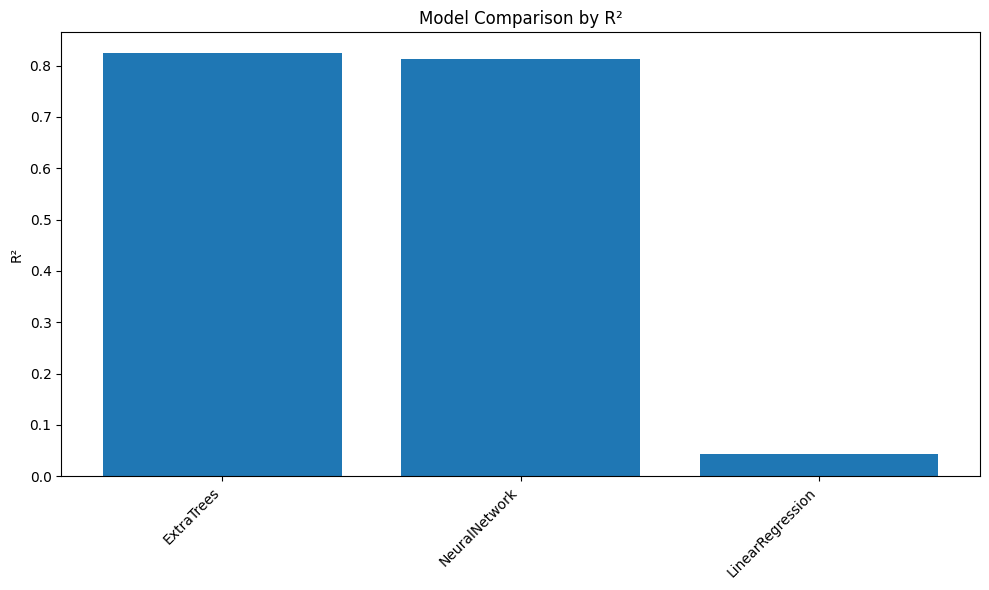

In [31]:
plt.figure(figsize=(10, 6))
plt.bar(results_df["Model"], results_df["R2"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("R²")
plt.title("Model Comparison by R²")
plt.tight_layout()
plt.show()

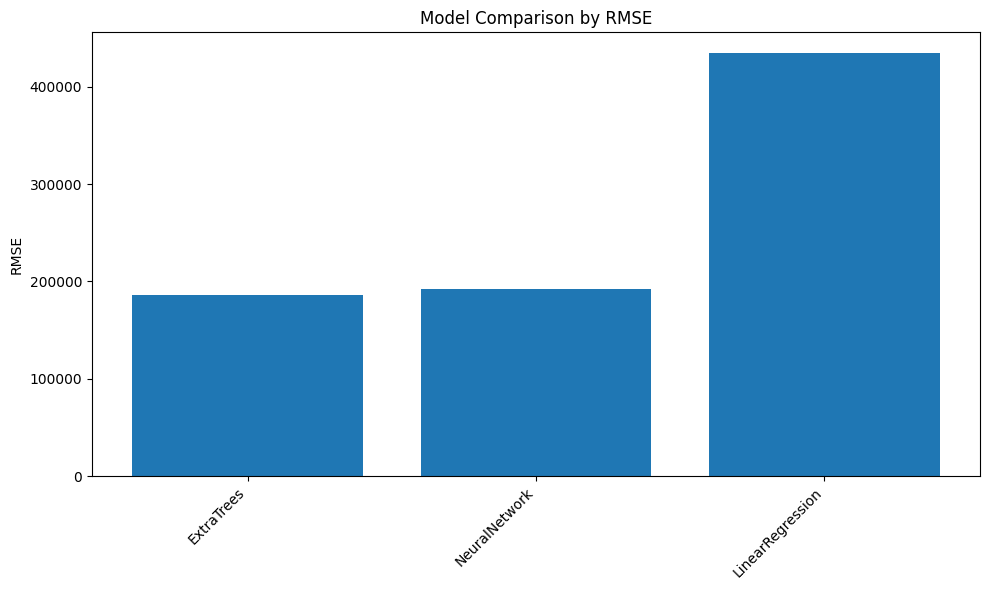

In [32]:
# RMSE
plt.figure(figsize=(10, 6))
plt.bar(results_df["Model"], results_df["RMSE"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("RMSE")
plt.title("Model Comparison by RMSE")
plt.tight_layout()
plt.show()

## feature importance for best tree model

In [33]:
# extratrees is our best model
best_model = fitted_models["ExtraTrees"]

feature_names = preprocessor.get_feature_names_out()
importances = best_model.feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

importance_df.head(15)

,Feature,Importance
6,num__Log Assessed Value,0.287875
1,num__Assessed Value,0.190462
11,num__Dist To Boston,0.046077
9,num__Dist To NYC,0.041577
0,num__List Year,0.040434
2,num__Sale Year,0.039223
190,cat__Residential Type_Single Family,0.038339
10,num__Dist To Hartford,0.036557
8,num__Longitude,0.032302
5,num__Sale Day Of Year,0.029491


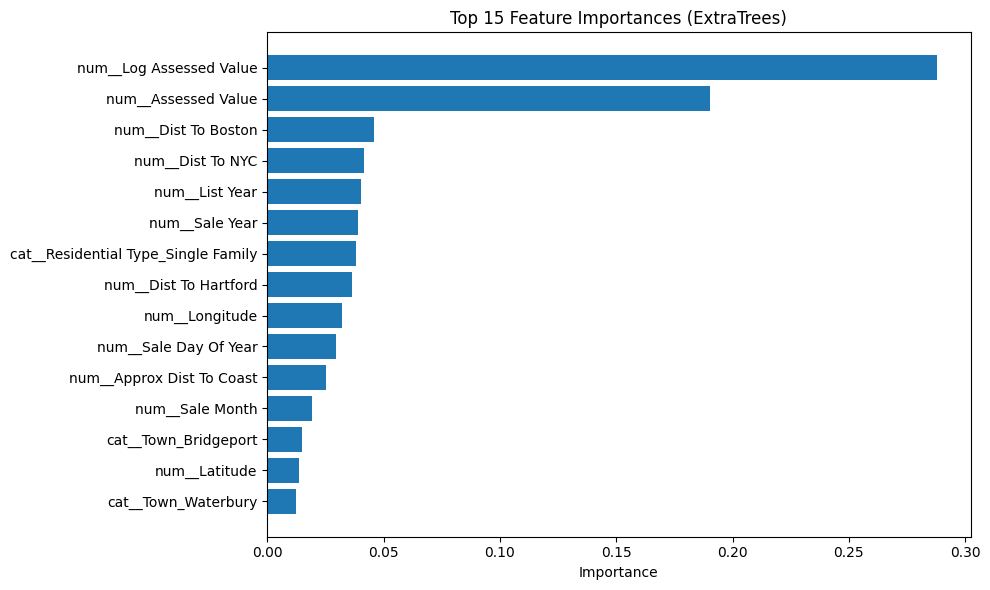

In [34]:
# plot top 15
top_k = 15
top_df = importance_df.head(top_k).sort_values(by="Importance")

plt.figure(figsize=(10, 6))
plt.barh(top_df["Feature"], top_df["Importance"])
plt.xlabel("Importance")
plt.title("Top 15 Feature Importances (ExtraTrees)")
plt.tight_layout()
plt.show()

In [35]:
importance_df.to_csv("../results/feature_importance_extratrees.csv", index=False)

## prediction scatterplot for best model (extratrees)

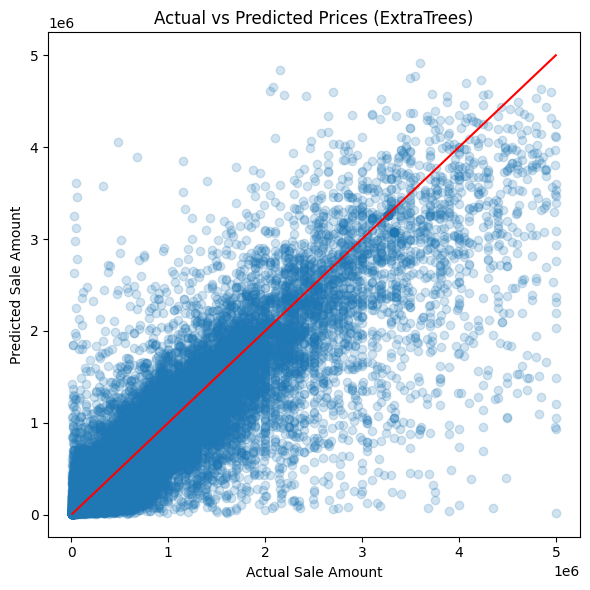

In [36]:
y_pred_log = best_model.predict(X_test_proc)
y_pred = np.expm1(y_pred_log)

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.2)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)
plt.xlabel("Actual Sale Amount")
plt.ylabel("Predicted Sale Amount")
plt.title("Actual vs Predicted Prices (ExtraTrees)")
plt.tight_layout()
plt.show()

# Results

- ExtraTrees model outperforms the baseline linear regression model significantly. 

- Linear Regression
    - RMSE: 434144
    - R^2: 0.0428
- ExtraTrees
    - RMSE: 186315
    - R^2: 0.824
- Neural Network
    - RMSE: 191844
    - R^2: 0.813

- Model improved significantly, 2.3x lower RMSE + R^2 from 0.04 -> 0.823
- Linear regression fails to capture the complex relationships and features that determine housing prices, while tree-based models can effectively represent nonlinear relationships and interactions
- This indicates that nonlinear relationships and interactions between features are crucial for understanding and predicting housing prices accurately
